In [84]:
""" 
Created on 16-08-2026

@author: B.A. Sturre

EDA for SaaS dataset 
"""

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# matplotlib setup
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif"
})

### Data reading and cleaning

In [74]:
# reading in the data 
accounts = pd.read_csv('data/ravenstack_accounts.csv')
churns = pd.read_csv('data/ravenstack_churn_events.csv')
feature = pd.read_csv('data/ravenstack_feature_usage.csv')
subs = pd.read_csv('data/ravenstack_subscriptions.csv')
support = pd.read_csv('data/ravenstack_support_tickets.csv')

# finding the columns
print('accounts columns: ', accounts.columns)
print('churns columns: ', churns.columns)
print('feature columns: ', feature.columns)
print('subs columns: ', subs.columns)
print('support columns: ', support.columns)

accounts columns:  Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='str')
churns columns:  Index(['churn_event_id', 'account_id', 'churn_date', 'reason_code',
       'refund_amount_usd', 'preceding_upgrade_flag',
       'preceding_downgrade_flag', 'is_reactivation', 'feedback_text'],
      dtype='str')
feature columns:  Index(['usage_id', 'subscription_id', 'usage_date', 'feature_name',
       'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature'],
      dtype='str')
subs columns:  Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag'],
      dtype='str')
support columns:  Index(['ticket_id', 'account_id', 'submitted_at', 'closed_at',
       'resolution_time_hours', 'priority', 'first_

In [75]:
# preprocessing data 

# aggregating feature usage by subscription id
feature_agg = feature.groupby('subscription_id').agg(
    total_usage_count=('usage_count', 'sum'),
    total_usage_duration_min=('usage_duration_secs', lambda x: x.sum() / 60),
    total_error_count=('error_count', 'sum')
).reset_index()

# aggregating support aggregation by account id 
support_agg = support.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_satisfaction_score=('satisfaction_score', 'mean'),
    total_escalations=('escalation_flag', 'sum')
).reset_index()

# merging datasets
df = subs.merge(feature_agg, on='subscription_id', how='left')
df = df.merge(accounts[['account_id', 'industry', 'country', 'referral_source']], on='account_id', how='left')
df = df.merge(support_agg, on='account_id', how='left')

# fill NaN values for accounts with zero usage
df['total_usage_count'] = df['total_usage_count'].fillna(0)
df['total_error_count'] = df['total_error_count'].fillna(0)
df['total_tickets'] = df['total_tickets'].fillna(0)
df['total_escalations'] = df['total_escalations'].fillna(0)

# create account size categories
df['account_size_category'] = pd.cut(
    df['seats'], 
    bins=[0, 5, 20, 50, np.inf], 
    labels=['Micro (1-5)', 'Small (6-20)', 'Medium (21-50)', 'Enterprise (50+)']
)

print(f"raw merged shape after data preprocessing: {df.shape[0]} rows, {df.shape[1]} columns")

raw merged shape after data preprocessing: 5000 rows, 25 columns


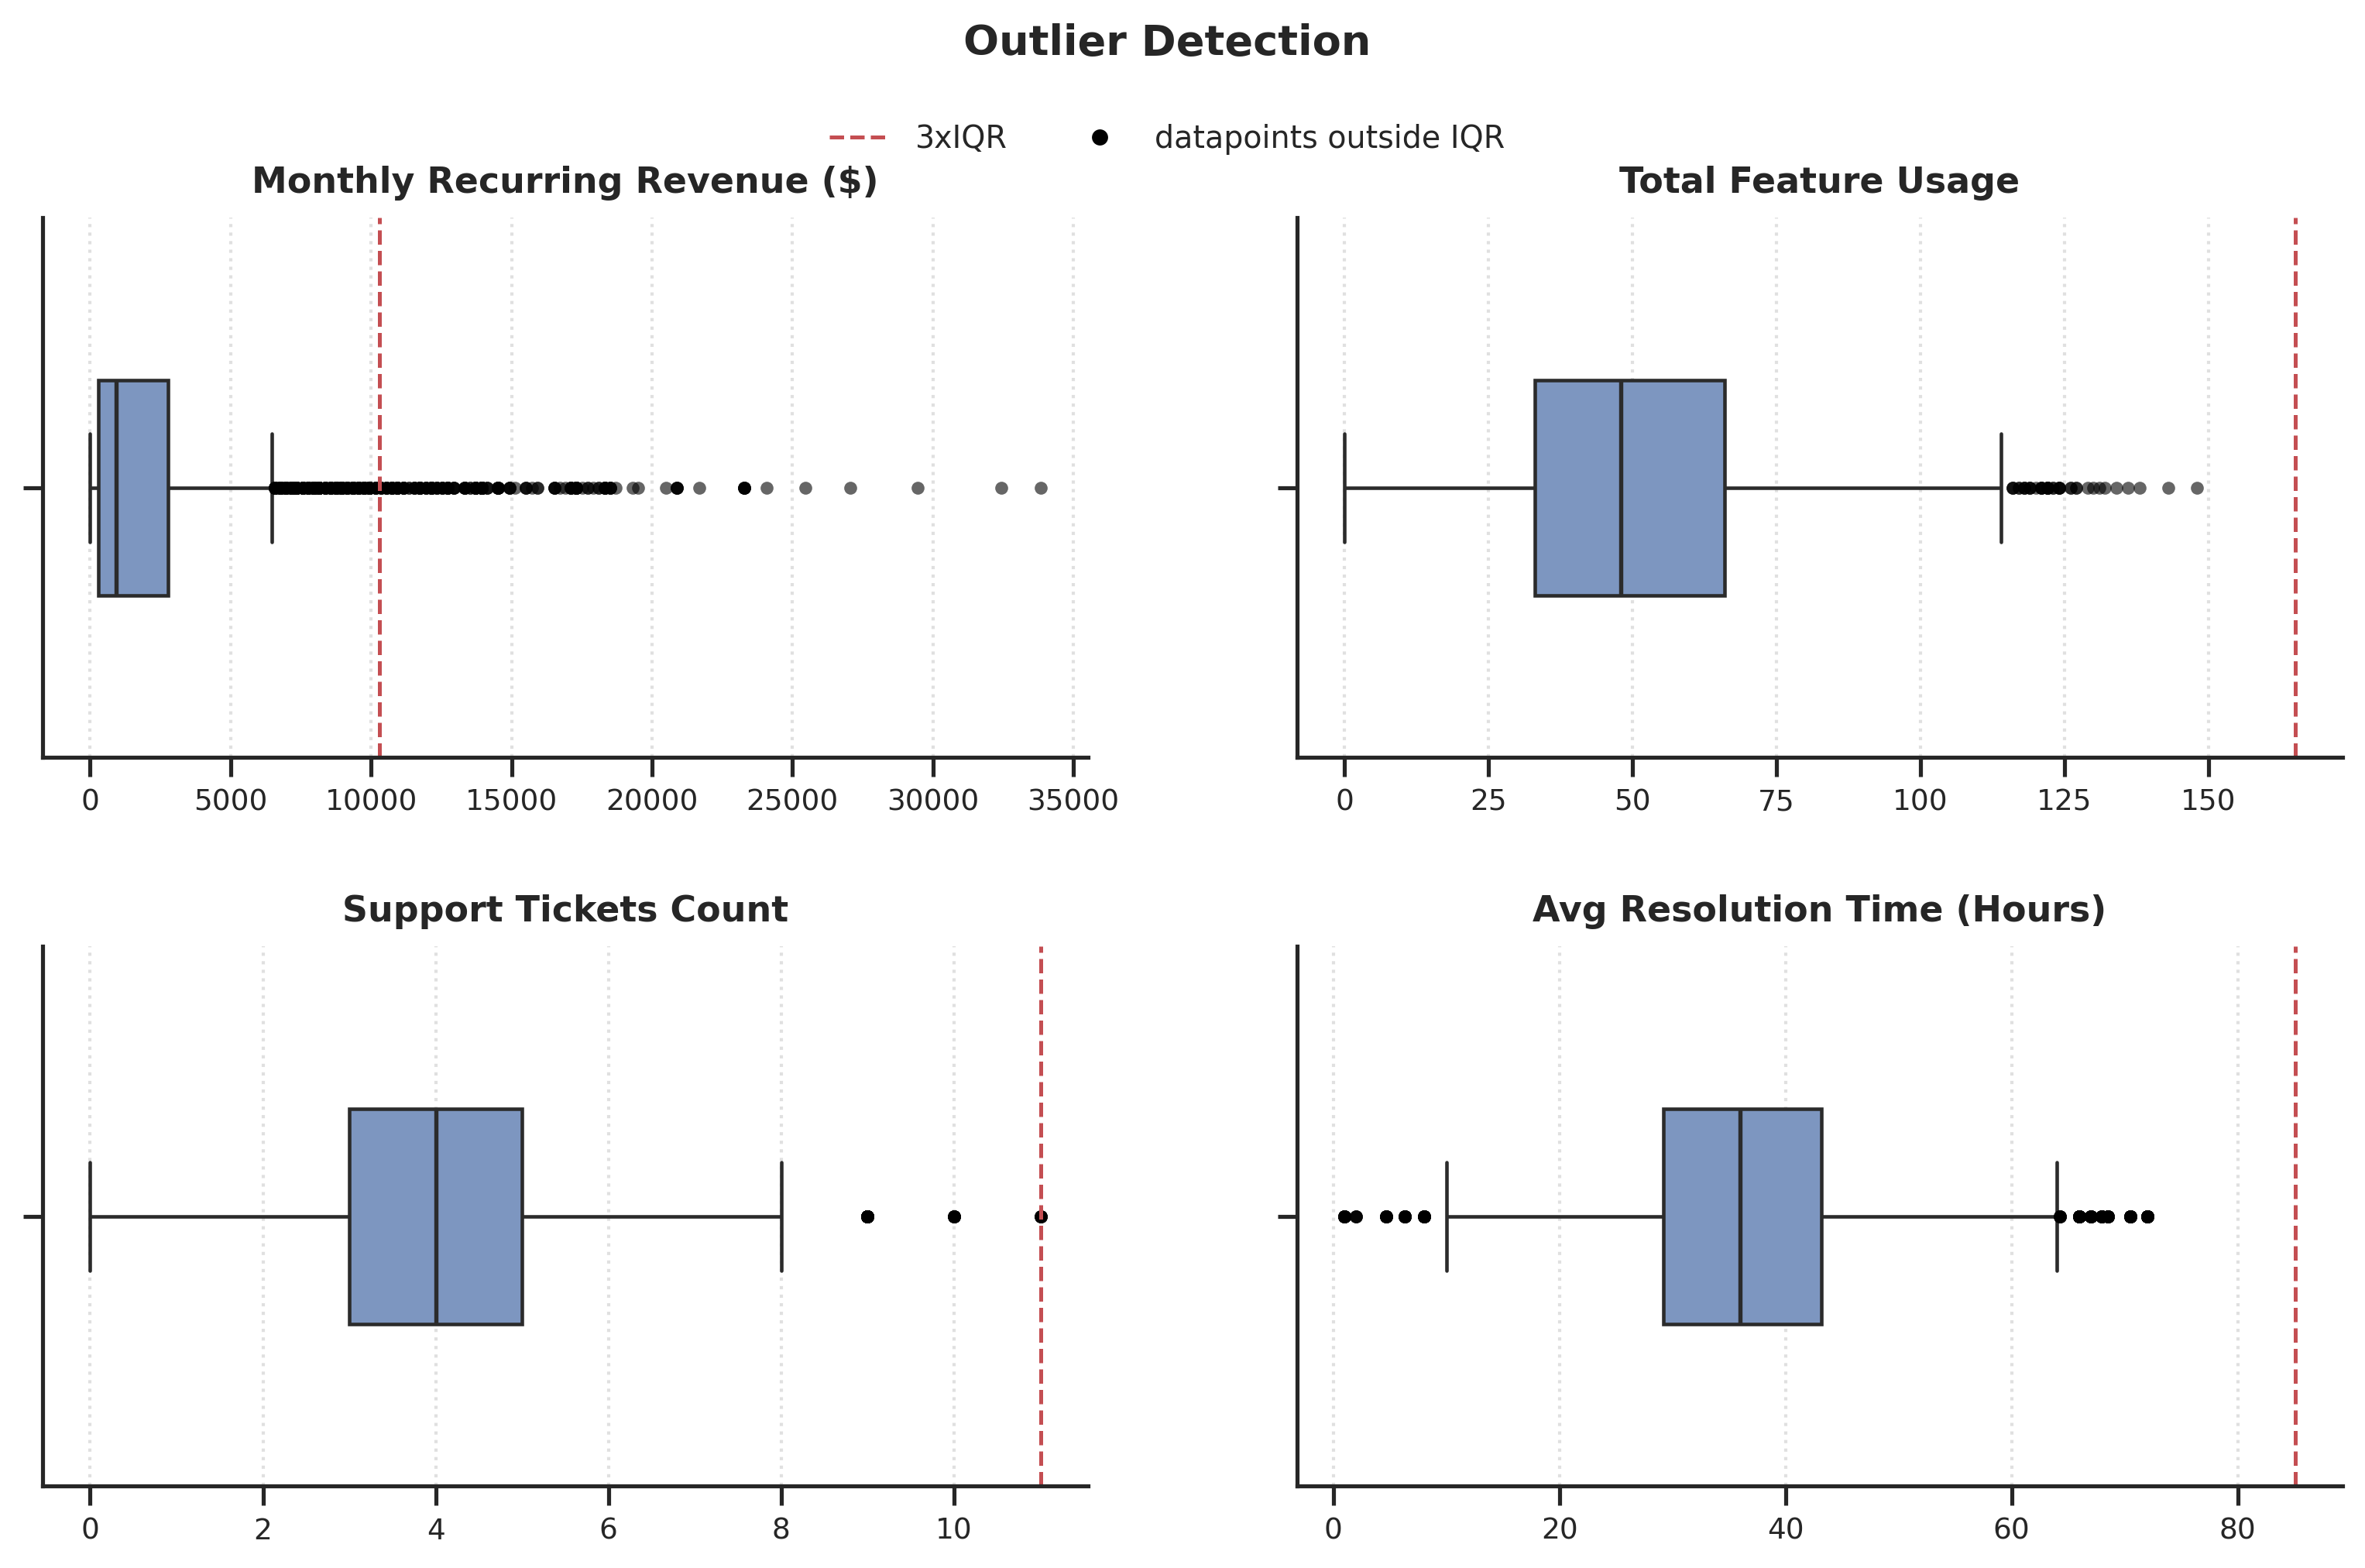

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional theme settings
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

# Column mapping for clean publication labels
metric_labels = {
    "mrr_amount": "Monthly Recurring Revenue ($)",
    "total_usage_count": "Total Feature Usage",
    "total_tickets": "Support Tickets Count",
    "avg_resolution_hours": "Avg Resolution Time (Hours)",
}

outlier_cols = list(metric_labels.keys())

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=False)
fig.suptitle(
    "Outlier Detection",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)

line_handle = None

for idx, col in enumerate(outlier_cols):
  ax = axes[idx // 2, idx % 2]

  # Calculate IQR & extreme cutoff
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  extreme_cutoff = q3 + 3.0 * iqr

  # Minimalist Boxplot
  sns.boxplot(
      x=df[col],
      ax=ax,
      color="#7293CB",
      width=0.4,
      fliersize=4,
      flierprops=dict(
          marker="o",
          markerfacecolor="black",
          markeredgecolor="none",
          alpha=0.6,
      ),
      boxprops=dict(edgecolor="#2B2B2B", linewidth=1.1),
      whiskerprops=dict(color="#2B2B2B", linewidth=1.1),
      capprops=dict(color="#2B2B2B", linewidth=1.1),
      medianprops=dict(color="#2B2B2B", linewidth=1.3),
  )

  # Cutoff line
  line = ax.axvline(
      extreme_cutoff,
      color="#C44E52",
      linestyle="--",
      linewidth=1.2,
      label="3xIQR",
  )
  if line_handle is None:
    line_handle = line

  # Clean presentation styling
  ax.set_title(metric_labels[col], fontweight="bold", pad=8)
  ax.set_xlabel("")
  ax.grid(True, axis="x", linestyle=":", alpha=0.6)
  sns.despine(ax=ax)

# Single unified legend at top
fig.legend(
    handles=[
        line_handle,
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="black",
            markersize=6,
            label="datapoints outside IQR",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncols=2,
    frameon=False,
    fontsize=9.5,
)

plt.subplots_adjust(
    top=0.86, bottom=0.08, left=0.06, right=0.96, hspace=0.35, wspace=0.2
)
plt.savefig('./figures/outlier_detection.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [77]:
def remove_outliers(df, columns, iqr_multiplier=3.0):
    df_clean = df.copy()
    initial_count = len(df_clean)
    
    print("--- Outlier Removal Summary ---")
    for col in columns:
        valid_data = df_clean[col].dropna()
        q1 = valid_data.quantile(0.25)
        q3 = valid_data.quantile(0.75)
        iqr = q3 - q1
        
        # outlier bounds
        upper_bound = q3 + (iqr_multiplier * iqr)
        lower_bound = q1 - (iqr_multiplier * iqr)
        
        # identify outliers
        outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outlier_mask.sum()
        
        # drop outliers
        df_clean = df_clean[~outlier_mask]
        print(f"Dropped {num_outliers} rows from '{col}' exceeding bounds [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    final_count = len(df_clean)
    dropped_total = initial_count - final_count
    print(f"\nTotal rows before: {initial_count}")
    print(f"Total rows after:  {final_count}")
    print(f"Total removed:     {dropped_total} ({dropped_total / initial_count * 100:.2f}% of dataset)")
    
    return df_clean


# remove outliers
df_clean = remove_outliers(
    df, 
    columns=['mrr_amount', 'total_usage_count', 'total_tickets', 'avg_resolution_hours'], 
    iqr_multiplier=3.0
)

--- Outlier Removal Summary ---
Dropped 199 rows from 'mrr_amount' exceeding bounds [-7218.00, 10289.00]
Dropped 0 rows from 'total_usage_count' exceeding bounds [-66.00, 165.00]
Dropped 0 rows from 'total_tickets' exceeding bounds [-3.00, 11.00]
Dropped 0 rows from 'avg_resolution_hours' exceeding bounds [-12.93, 85.20]

Total rows before: 5000
Total rows after:  4801
Total removed:     199 (3.98% of dataset)


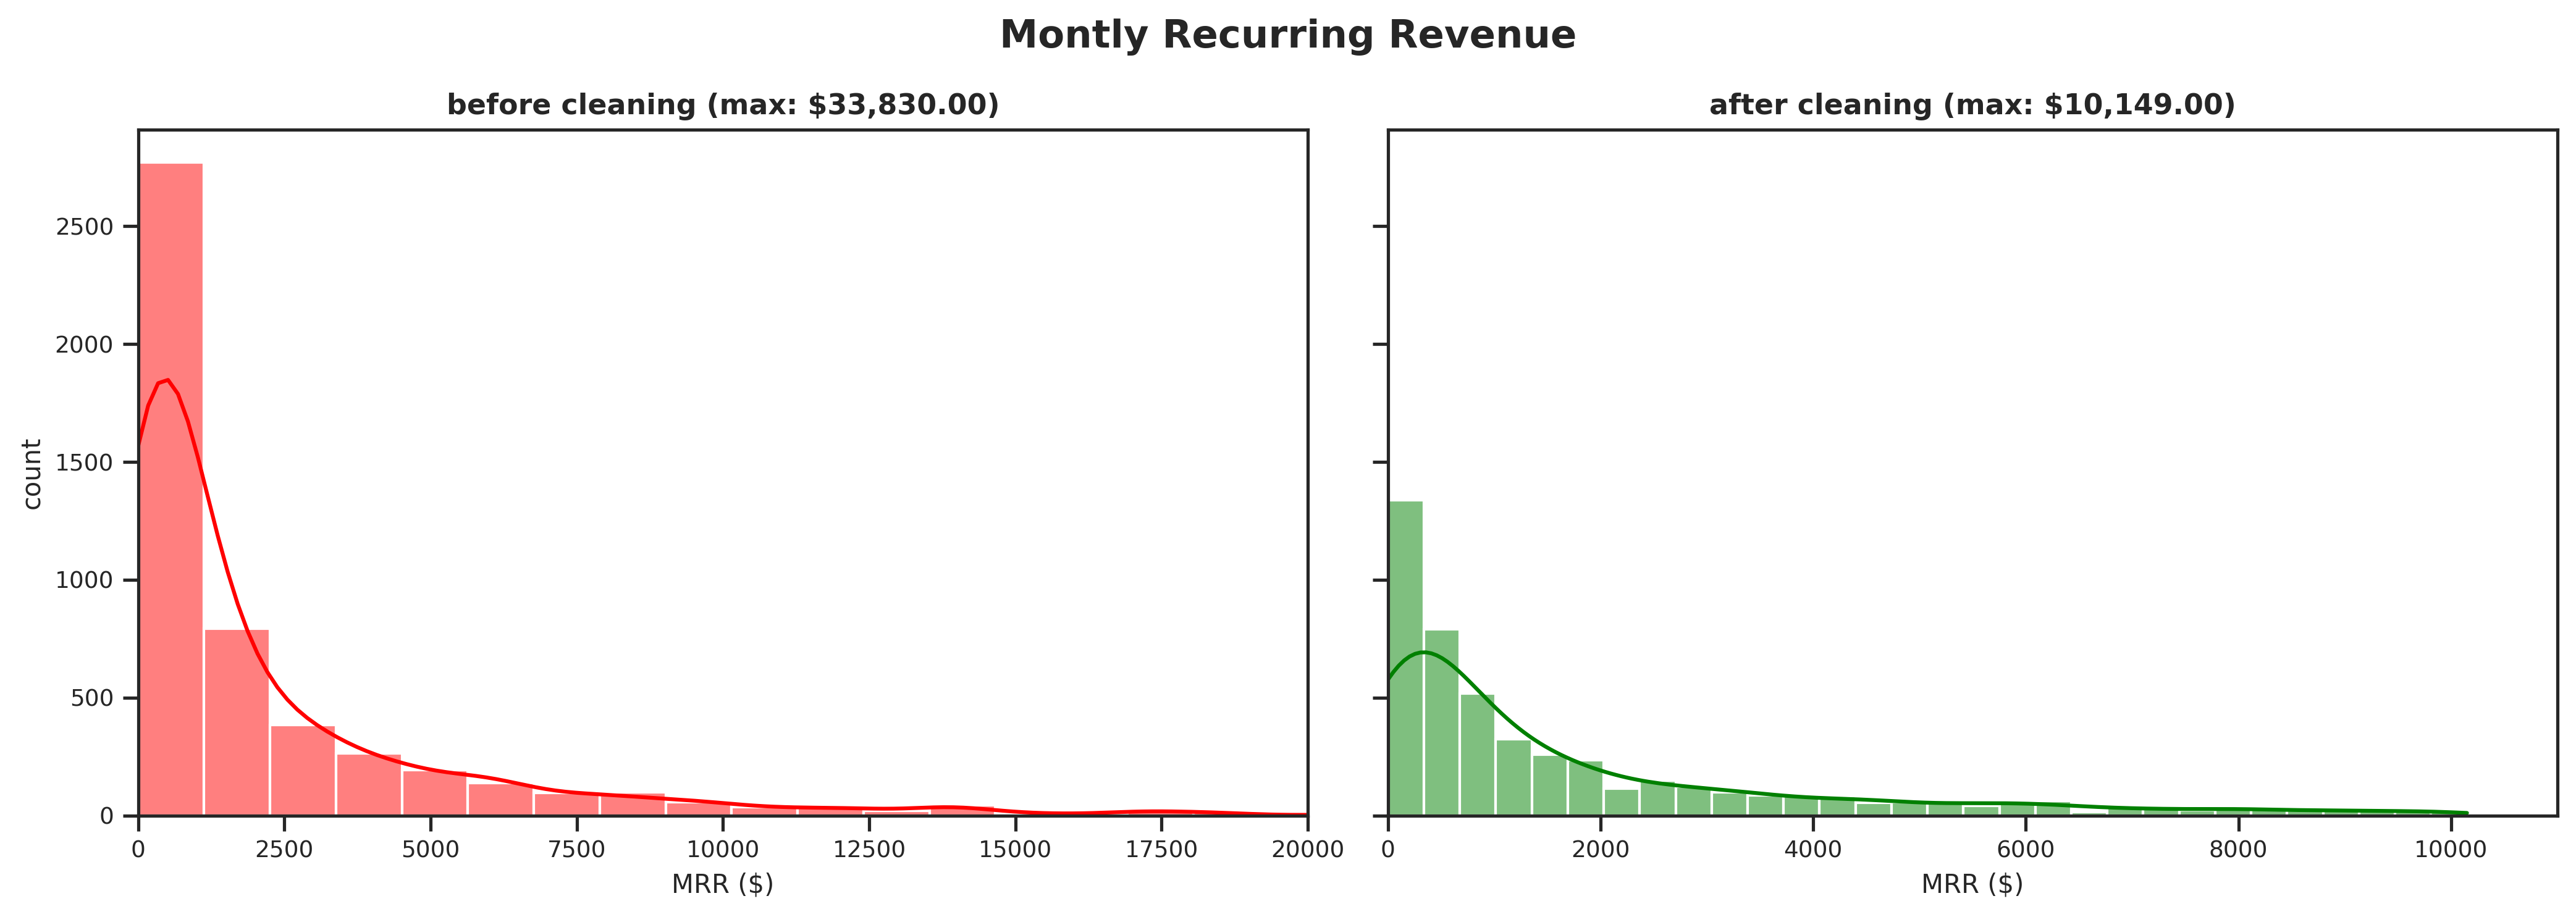

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# befoore cleaning
sns.histplot(df['mrr_amount'], kde=True, ax=axes[0], color='red', bins=30)
axes[0].set_title(f"before cleaning (max: ${df['mrr_amount'].max():,.2f})", fontweight='bold')
axes[0].set_xlim(0, 20000)
axes[0].set_ylabel('count')
axes[0].set_xlabel('MRR ($)')

# after cleaning
sns.histplot(df_clean['mrr_amount'], kde=True, ax=axes[1], color='green', bins=30)
axes[1].set_title(f"after cleaning (max: ${df_clean['mrr_amount'].max():,.2f})", fontweight='bold')
axes[1].set_xlim(0, 11000)
axes[1].set_xlabel('MRR ($)')

plt.suptitle('Montly Recurring Revenue', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.savefig('./figures/distributions_before_after_cleaning.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Descriptive Statistics

                metric     mean  median  min      max    range      std  skewness
            mrr_amount  1751.48   833.0  0.0  10149.0  10149.0  2202.27      1.76
            arr_amount 21017.80  9996.0  0.0 121788.0 121788.0 26427.25      1.76
                 seats    28.02    23.0  1.0    189.0    188.0    21.33      2.04
     total_usage_count    50.09    48.0  0.0    148.0    148.0    23.39      0.47
         total_tickets     3.98     4.0  0.0     11.0     11.0     1.85      0.41
  avg_resolution_hours    36.42    36.0  1.0     72.0     71.0    11.91      0.24
avg_satisfaction_score     3.97     4.0  3.0      5.0      2.0     0.58      0.00


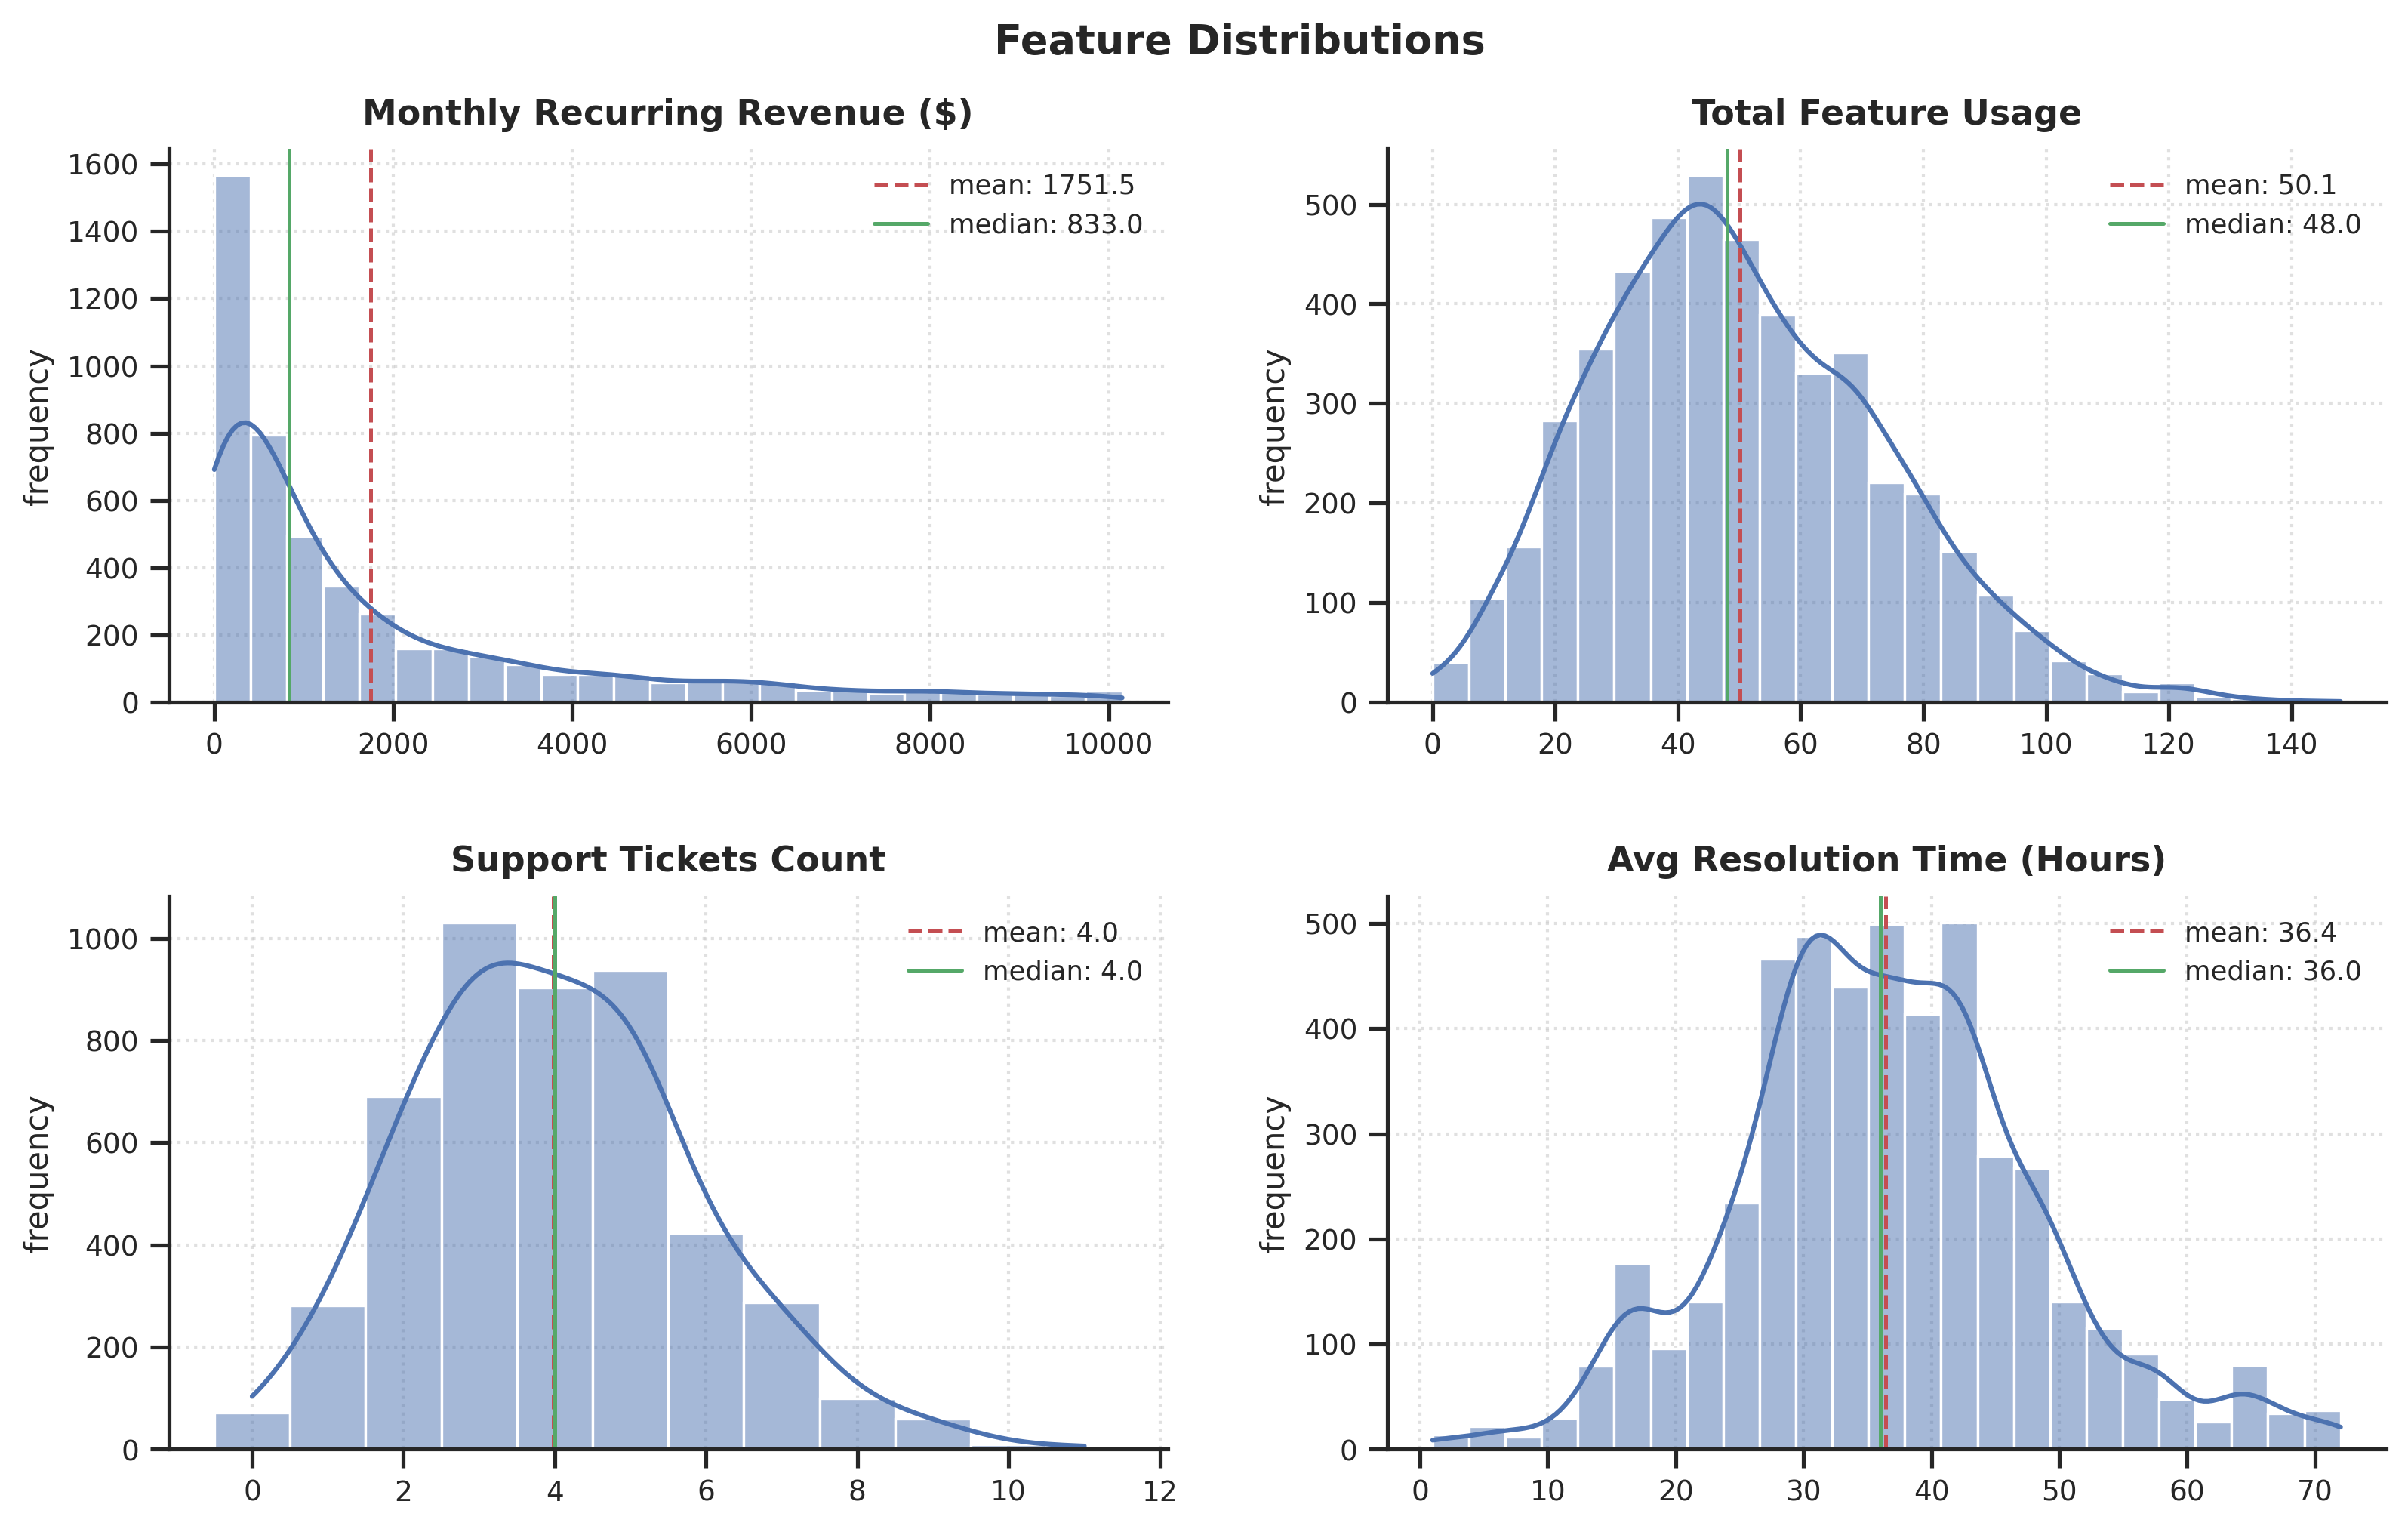

In [79]:
# statistics columns in the data
stats_cols = [
    "mrr_amount",
    "arr_amount",
    "seats",
    "total_usage_count",
    "total_tickets",
    "avg_resolution_hours",
    "avg_satisfaction_score",
]

# getting stats
def descriptive_stats(data, columns):
  stats_list = []
  for col in columns:
    s = data[col].dropna()
    stats_list.append({
        "metric": col,
        "mean": round(s.mean(), 2),
        "median": round(s.median(), 2),
        "min": round(s.min(), 2),
        "max": round(s.max(), 2),
        "range": round(s.max() - s.min(), 2),
        "std": round(s.std(), 2),
        "skewness": round(s.skew(), 2),
    })
  return pd.DataFrame(stats_list)

# getting descriptive statistics for the dataset
desc_stats_df = descriptive_stats(df_clean, stats_cols)
print(desc_stats_df.to_string(index=False))

# labels for plotting
metric_labels = {
    "mrr_amount": "Monthly Recurring Revenue ($)",
    "total_usage_count": "Total Feature Usage",
    "total_tickets": "Support Tickets Count",
    "avg_resolution_hours": "Avg Resolution Time (Hours)",
}

# plotting 
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle(
    "Feature Distributions",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)

# looping over columns
for idx, col in enumerate(outlier_cols):
  ax = axes[idx // 2, idx % 2]

  # histogram
  if col == "total_tickets":
    sns.histplot(
        df_clean[col],
        discrete=True,
        kde=True,
        kde_kws={"bw_adjust": 2.0},
        ax=ax,
        color="#4C72B0",
        edgecolor="white",
        linewidth=0.8,
    )
  else:
    sns.histplot(
        df_clean[col],
        kde=True,
        ax=ax,
        color="#4C72B0",
        bins=25,
        edgecolor="white",
        linewidth=0.8,
    )

  # mean and median lines
  mean_val = df_clean[col].mean()
  median_val = df_clean[col].median()

  ax.axvline(
      mean_val,
      color="#C44E52",
      linestyle="--",
      linewidth=1.2,
      label=f"mean: {mean_val:.1f}",
  )
  ax.axvline(
      median_val,
      color="#55A868",
      linestyle="-",
      linewidth=1.2,
      label=f"median: {median_val:.1f}",
  )

  # plotting
  ax.set_title(metric_labels[col], fontweight="bold", pad=8)
  ax.set_xlabel("")
  ax.set_ylabel("frequency")
  ax.legend(frameon=False, fontsize=8.5)
  ax.grid(True, linestyle=":", alpha=0.6)
  sns.despine(ax=ax)

plt.subplots_adjust(
    top=0.90, bottom=0.08, left=0.07, right=0.96, hspace=0.35, wspace=0.22
)
plt.savefig('./figures/descriptive_stats.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

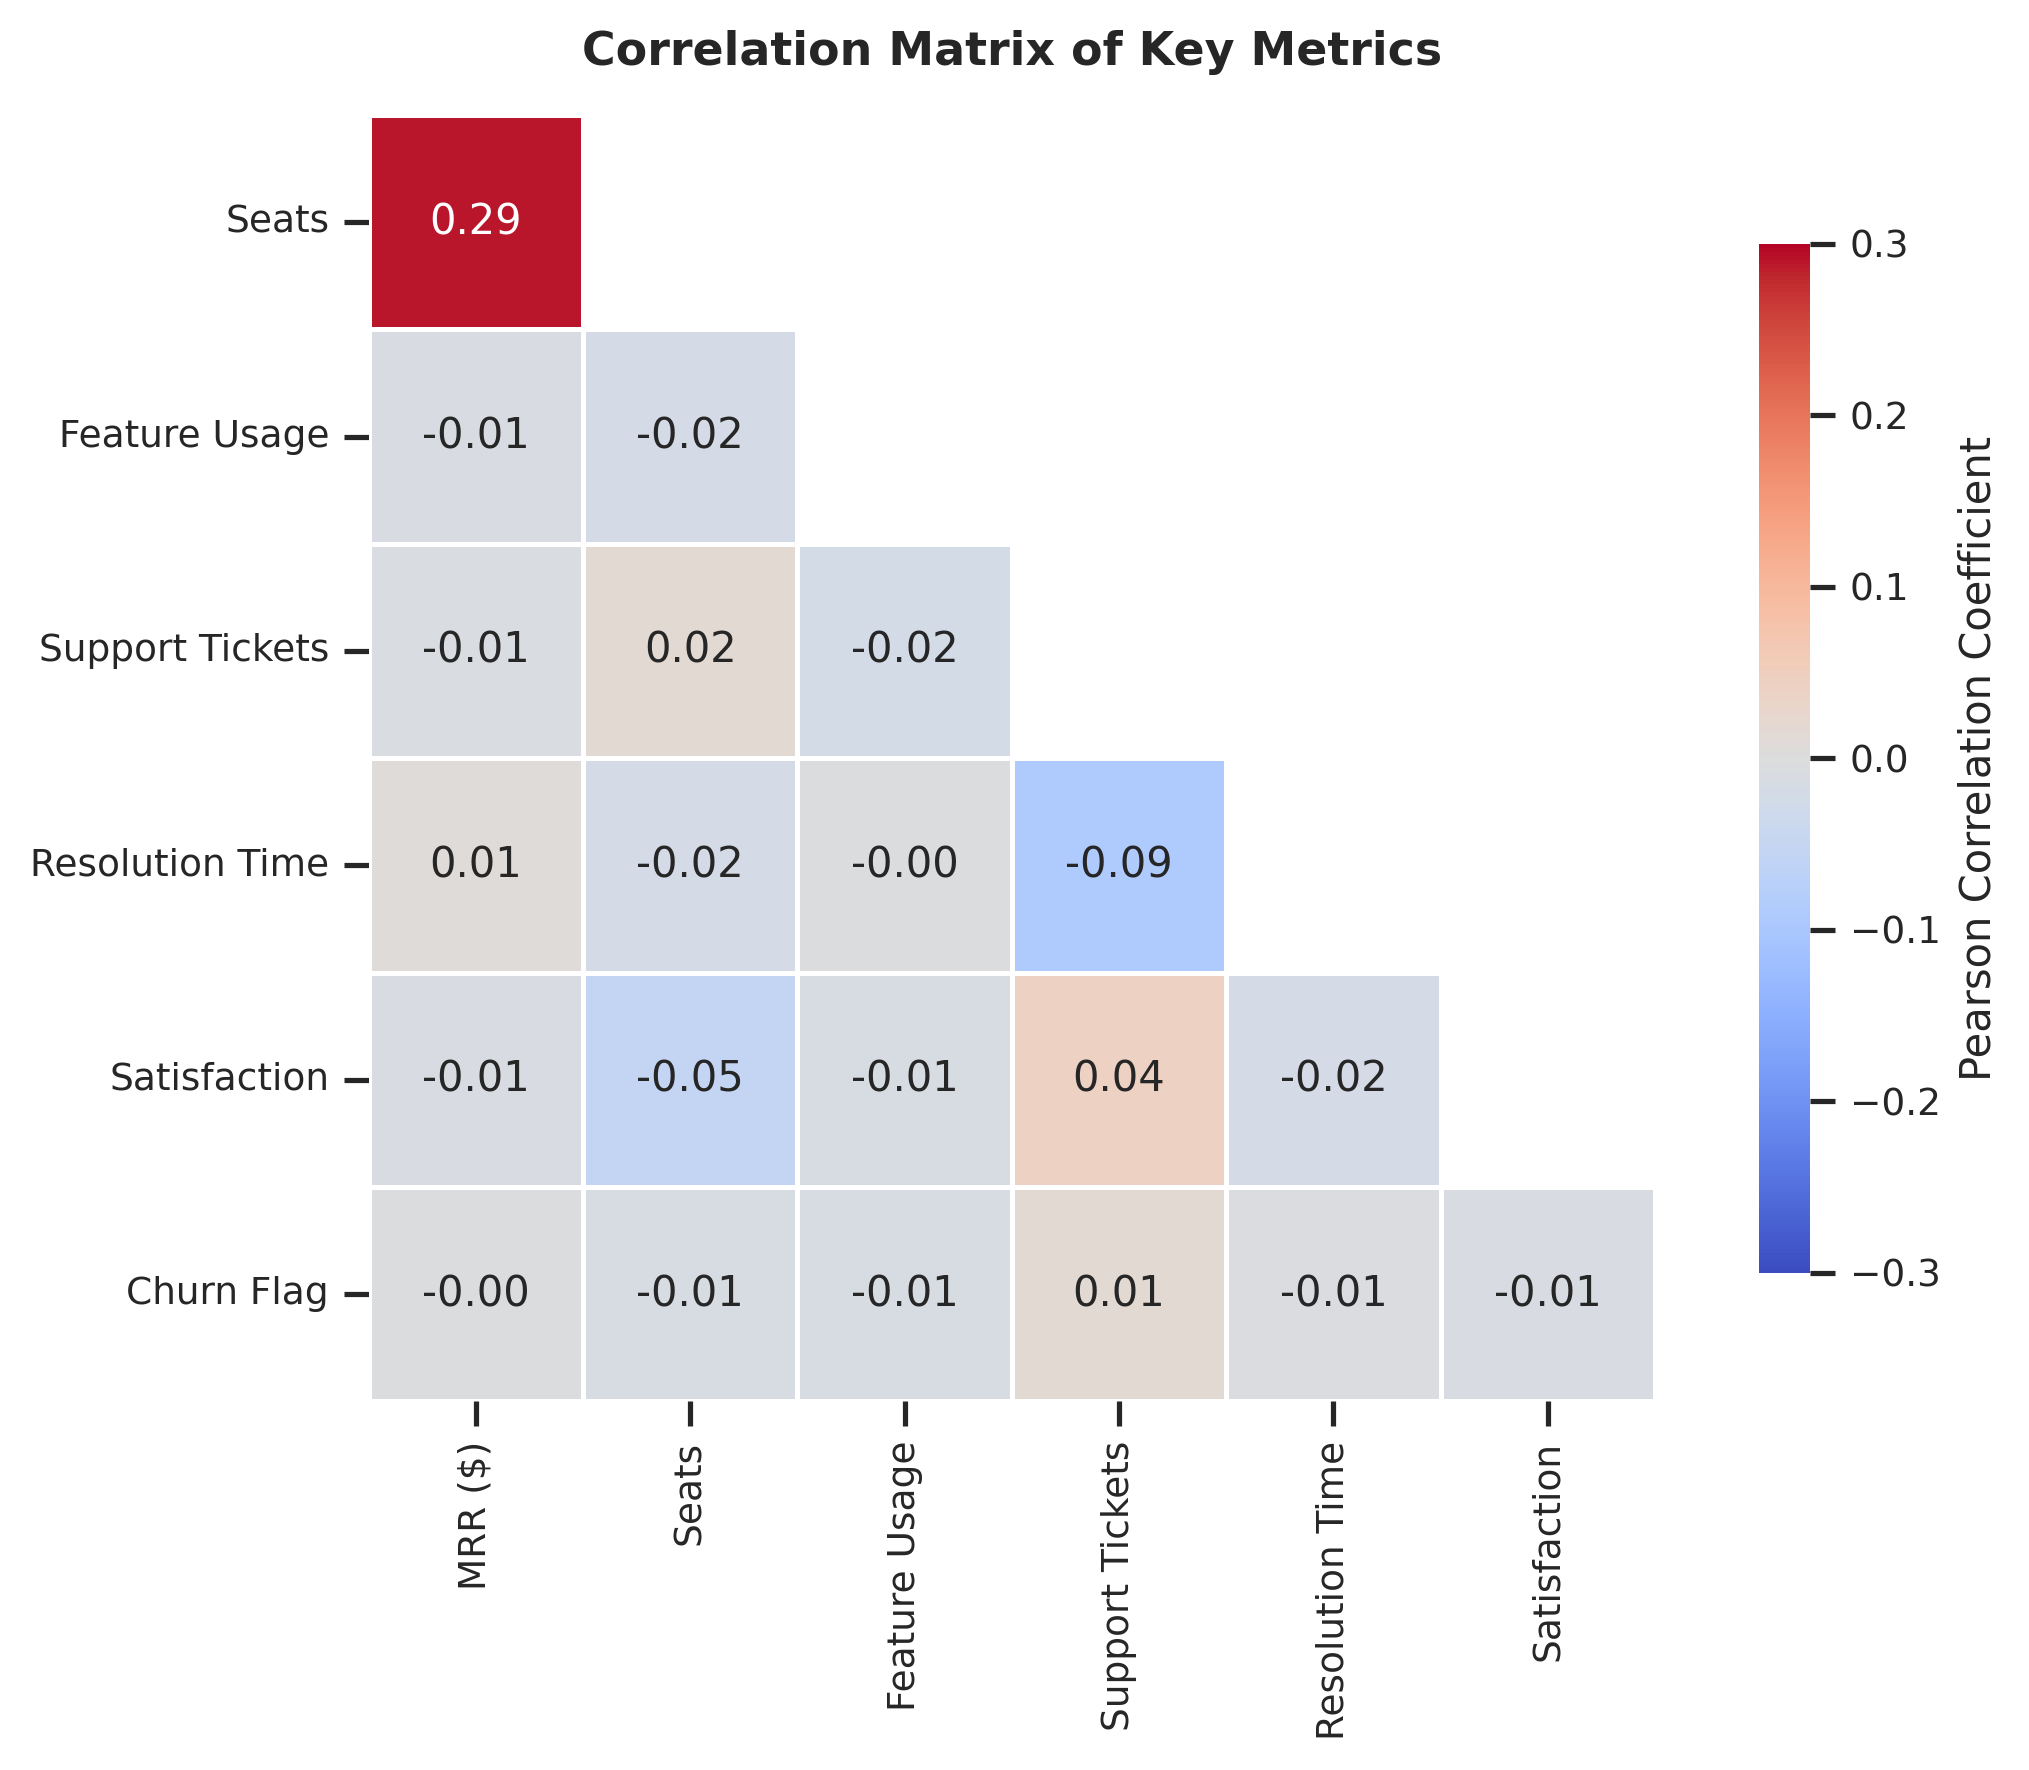

In [80]:
# columns for correlation matrix
corr_cols = [
    "mrr_amount",
    "seats",
    "total_usage_count",
    "total_tickets",
    "avg_resolution_hours",
    "avg_satisfaction_score",
    "churn_flag",
]

# labels 
corr_labels = {
    "mrr_amount": "MRR ($)",
    "seats": "Seats",
    "total_usage_count": "Feature Usage",
    "total_tickets": "Support Tickets",
    "avg_resolution_hours": "Resolution Time",
    "avg_satisfaction_score": "Satisfaction",
    "churn_flag": "Churn Flag",
}

# computing correlation matrix
corr_matrix = df_clean[corr_cols].corr()
corr_matrix.rename(index=corr_labels, columns=corr_labels, inplace=True)

# lower-triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_matrix_sub = corr_matrix.iloc[1:, :-1]
mask_sub = mask[1:, :-1]

# correlation heatmap plotting
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix_sub,
    mask=mask_sub,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.3,
    vmax=0.3,
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"},
    ax=ax,
)

ax.set_title("Correlation Matrix of Key Metrics", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("./figures/correlation_matrix.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

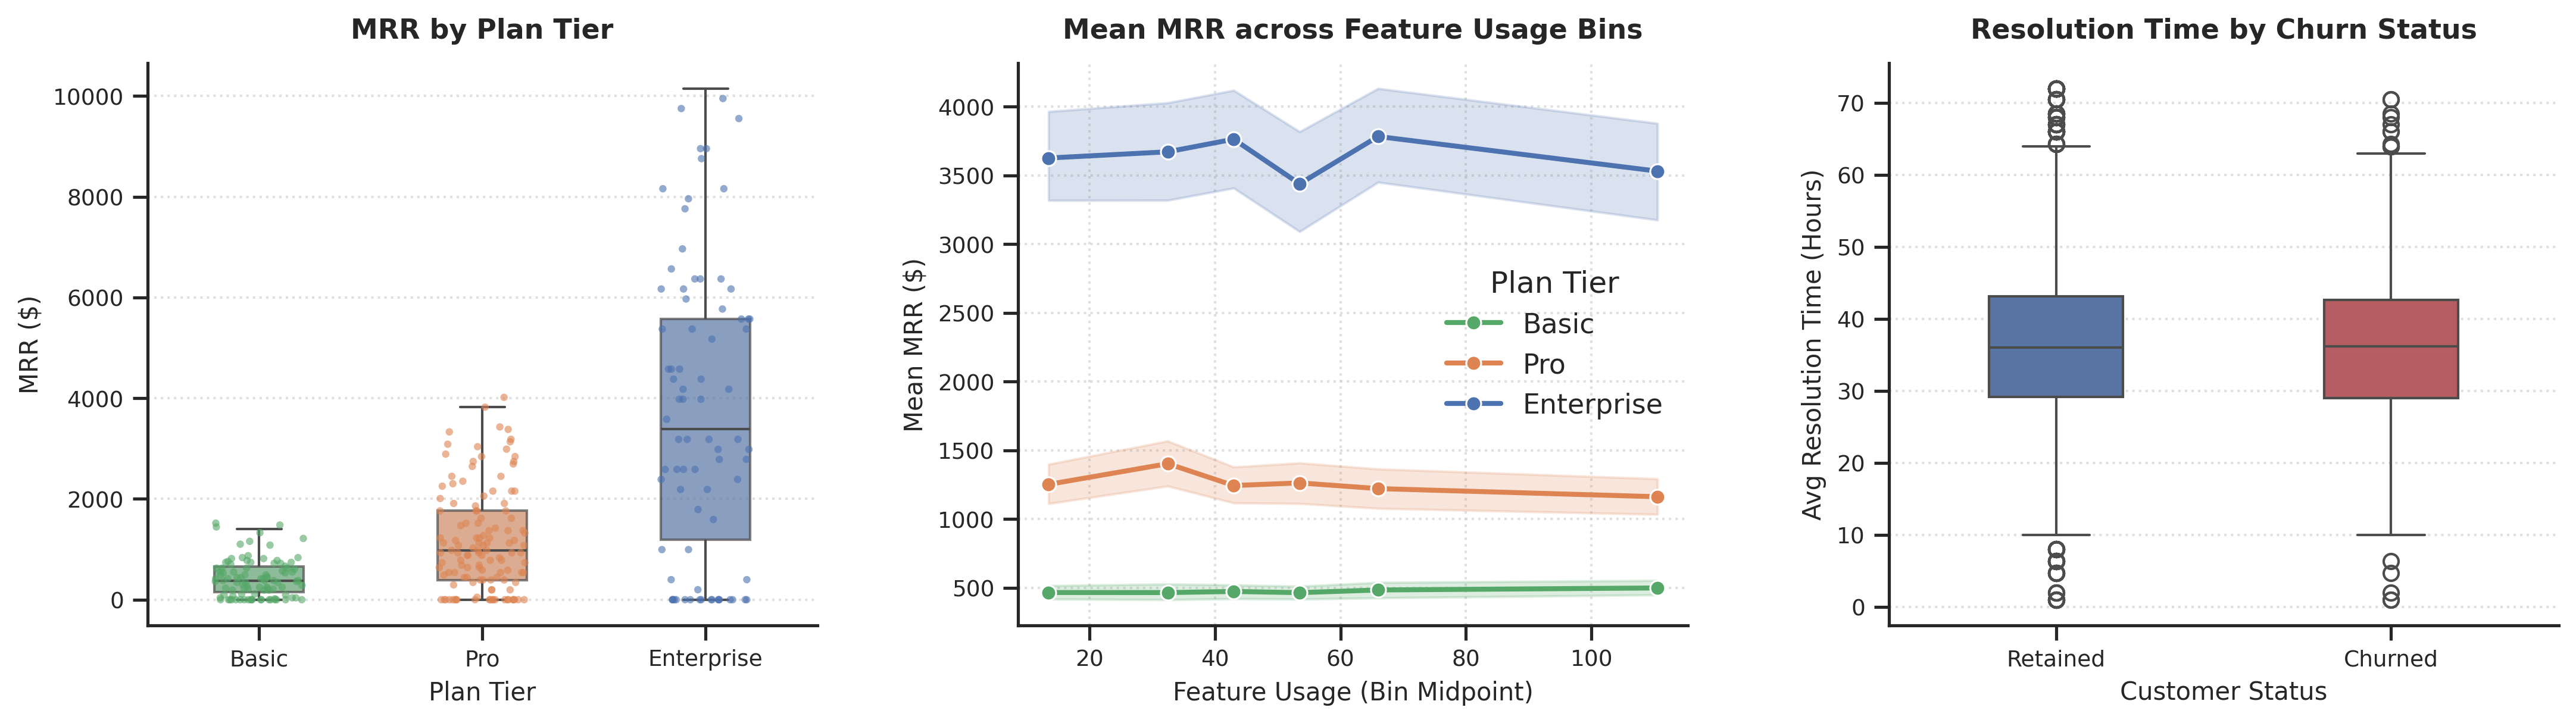

In [81]:
# plotting bivariate distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# MMR by tier
tier_order = ["Basic", "Pro", "Enterprise"]
tier_colors = {"Basic": "#55A868", "Pro": "#DD8452", "Enterprise": "#4C72B0"}

sns.boxplot(
    data=df_clean,
    x="plan_tier",
    y="mrr_amount",
    hue="plan_tier", 
    legend=False,
    order=tier_order,
    palette=tier_colors,
    width=0.4,
    fliersize=0,
    ax=axes[0],
    boxprops=dict(alpha=0.7)
)

sns.stripplot(
    data=df_clean.sample(min(300, len(df_clean)), random_state=42),
    x="plan_tier",
    y="mrr_amount",
    hue="plan_tier",
    legend=False,
    order=tier_order,
    palette=tier_colors,
    size=3,
    alpha=0.6,
    jitter=0.2,
    ax=axes[0]
)

axes[0].set_title("MRR by Plan Tier", fontweight="bold", pad=10)
axes[0].set_xlabel("Plan Tier")
axes[0].set_ylabel("MRR ($)")
axes[0].grid(True, axis="y", linestyle=":", alpha=0.6)
sns.despine(ax=axes[0])


# feature usage vs MMR
df_clean_binned = df_clean.copy()

# quantile bins
df_clean_binned["usage_interval"] = pd.qcut(df_clean_binned["total_usage_count"], q=6, duplicates="drop")
df_clean_binned["usage_bin"] = df_clean_binned["usage_interval"].apply(lambda x: x.mid).astype(float)

# plotting
sns.lineplot(
    data=df_clean_binned,
    x="usage_bin",
    y="mrr_amount",
    hue="plan_tier",
    hue_order=tier_order,
    palette=tier_colors,
    marker="o",
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Mean MRR across Feature Usage Bins", fontweight="bold", pad=10)
axes[1].set_xlabel("Feature Usage (Bin Midpoint)")
axes[1].set_ylabel("Mean MRR ($)")
axes[1].legend(title="Plan Tier", frameon=False)
axes[1].grid(True, linestyle=":", alpha=0.6)
sns.despine(ax=axes[1])


# support metric vs churn rate
sns.boxplot(
    data=df_clean,
    x="churn_flag",
    y="avg_resolution_hours",
    hue="churn_flag",
    palette=["#4C72B0", "#C44E52"],
    legend=False,
    width=0.4,
    ax=axes[2]
)

axes[2].set_title("Resolution Time by Churn Status", fontweight="bold", pad=10)
axes[2].set_xlabel("Customer Status")
axes[2].set_ylabel("Avg Resolution Time (Hours)")

axes[2].set_xticks([0, 1])                                 # Fixed: Set ticks first
axes[2].set_xticklabels(["Retained", "Churned"])   # Set tick labels safely

axes[2].grid(True, axis="y", linestyle=":", alpha=0.6)
sns.despine(ax=axes[2])

plt.subplots_adjust(top=0.88, bottom=0.18, left=0.06, right=0.96, wspace=0.3)
plt.savefig("./figures/bivariate_analysis.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

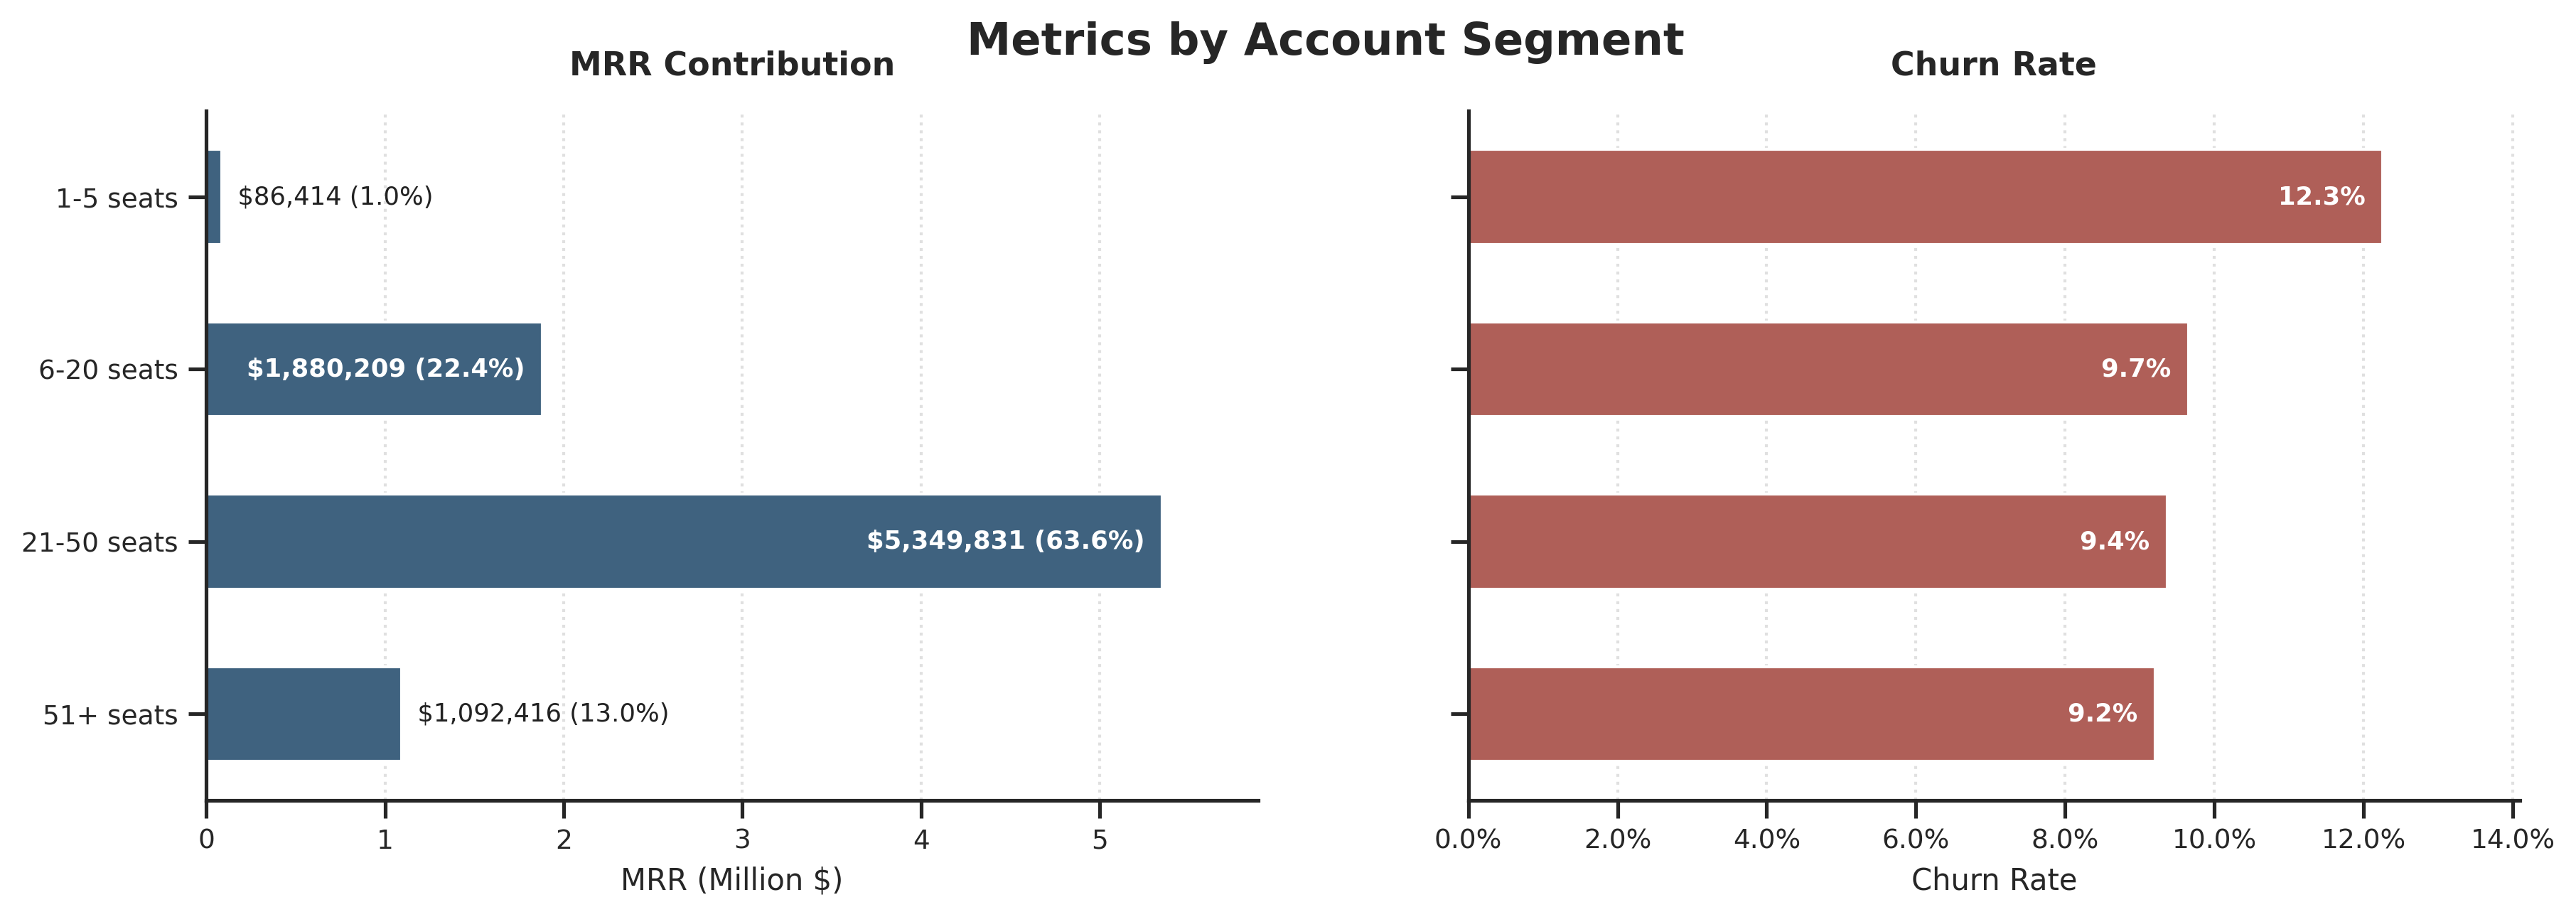

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FuncFormatter

df_segmented = df_clean.copy()

# segment accounts by seat count
seat_bins = [0, 5, 20, 50, np.inf]
seat_labels = ["1-5 seats", "6-20 seats", "21-50 seats", "51+ seats"]
df_segmented["account_size_segment"] = pd.cut(df_segmented["seats"], bins=seat_bins, labels=seat_labels)

# metrics into df
summary_by_segment = (
    df_segmented.groupby("account_size_segment", observed=False)
    .agg(
        account_count=("mrr_amount", "count"),
        total_mrr=("mrr_amount", "sum"),
        avg_mrr=("mrr_amount", "mean"),
        median_mrr=("mrr_amount", "median"),
        avg_seats=("seats", "mean"),
        churn_rate=("churn_flag", "mean"),
    )
    .reset_index()
)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)

# MRR contribution
mrr_color = "#34638a"

sns.barplot(
    data=summary_by_segment,
    y="account_size_segment",
    x="total_mrr",
    color=mrr_color,
    width=0.55,
    ax=axes[0]
)

axes[0].set_title("MRR Contribution", fontweight="bold", pad=12)
axes[0].set_xlabel("MRR (Million $)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:g}"))
axes[0].grid(True, axis="x", linestyle=":", alpha=0.6)

max_mrr = summary_by_segment["total_mrr"].max()
axes[0].set_xlim(0, max_mrr * 1.1)

# putting text on histogram
for p in axes[0].patches:
    val = p.get_width()
    pct = (val / summary_by_segment["total_mrr"].sum()) * 100
    text_label = f"${val:,.0f} ({pct:.1f}%)"
    
    if val > max_mrr * 0.25:
        axes[0].annotate(
            f"{text_label}  ",
            (val, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="white"
        )
    else:
        axes[0].annotate(
            f"  {text_label}",
            (val, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="medium",
            color="#222222"
        )

sns.despine(ax=axes[0])


# churn rate by segment
churn_color = "#bd534a"

sns.barplot(
    data=summary_by_segment,
    y="account_size_segment",
    x="churn_rate",
    color=churn_color,
    width=0.55,
    ax=axes[1]
)

axes[1].set_title("Churn Rate", fontweight="bold", pad=12)
axes[1].set_ylabel("")
axes[1].set_xlabel("Churn Rate")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(True, axis="x", linestyle=":", alpha=0.6)

max_churn = summary_by_segment["churn_rate"].max()
axes[1].set_xlim(0, max_churn * 1.15)

# text on histogram
for p in axes[1].patches:
    val = p.get_width()
    text_label = f"{val:.1%}"
    
    if val > max_churn * 0.3:
        axes[1].annotate(
            f"{text_label}  ",
            (val, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="white"
        )
    else:
        axes[1].annotate(
            f"  {text_label}",
            (val, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="medium",
            color="#222222"
        )

sns.despine(ax=axes[1])
plt.suptitle("Metrics by Account Segment", fontweight='bold', fontsize=15)

plt.savefig("./figures/account_segmentation.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()